# Tables for paper

## Segmentation

### Setup

In [24]:
# imports
from dataclasses import dataclass
from __future__ import annotations
from IPython.display import display
import json
import math
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import pandas as pd
from pathlib import Path
import re
from scipy.ndimage import label as cc_label
import tifffile as tiff
from typing import Dict, List, Optional, Tuple
import warnings


In [25]:
# define constants
PROB_THRESHOLD = 0.5
STRUCT_3D_26 = np.ones((3, 3, 3), dtype=bool)
PATCH_ID_RE = re.compile(r"(patch_\d{3})")
VOL_RE = re.compile(r"(vol\d{3})")
CH_RE = re.compile(r"(ch[01])")
DECIMALS = 2

# datatype mapping
DTYPES_GT = ["amyloid_plaque_patches", "cell_nucleus_patches", "vessels_patches"]
DTYPE_CANON = {
    "amyloid_plaque_patches": "Amyloid Plaque",
    "cell_nucleus_patches": "Cell Nucleus",
    "vessels_patches": "Vessels",
}

DTYPE_FEWMANY_ALIASES = {
    "amyloid_plaque_patches": ["amyloid_plaque", "amyloid_plaque_patches"],
    "cell_nucleus_patches": ["cell_nucleus", "cell_nucleus_patches"],
    "vessels_patches": ["vessels", "vessels_patches"],
}

# shot definitions
SHOTS = {
    "Zero-shot": {"mode": "zeroshot"},
    "Few-shot":  {"mode": "fewmany", "ntr": 5},
    "Many-shot": {"mode": "fewmany", "ntr": 15},
}

# folds
FOLDS = [0, 1, 2]

# define variables
ZEROSHOT_EXCLUDE = {
    "SwinUNETR Image+CLIP (overtrain)",
    "microSAM base",
    "microSAM large",
    "CellSeg3D",
    "Cellpose 2D",
    "Cellpose 3D",
}


In [26]:
# data paths

# ground truth
GT_ROOT = Path("/midtier/paetzollab/scratch/ads4015/data_selma3d/selma3d_finetune_patches")

# zeroshot
ZEROSHOT_ROOTS = {
    # Unet zeroshot preds: _zeroshot_unet, Swin: _zeroshot/results
    "unet_zeroshot_root": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_zeroshot_unet"),
    "swin_zeroshot_root": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_zeroshot"),
}

# few/many-shot
FEWMANY_ROOTS = {
    "Unet Image+CLIP": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_super_sweep2"),
    "Unet Image-only": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_bright_sweep_26"),
    "Unet Random-init": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_unet_random2"),

    "SwinUNETR Image+CLIP": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_autumn_sweep_27_v3"),
    "SwinUNETR Image+CLIP (overtrain)": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_autumn_sweep_27_long_v3"),
    "SwinUNETR Image-only": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_expert_sweep_31_v3"),
    "SwinUNETR Random-init": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_segmentation_preds_rand_v3"),

    "microSAM base": Path("/midtier/paetzollab/scratch/ads4015/compare_methods/micro_sam/finetuned_cross_val_b2"),
    "microSAM large": Path("/midtier/paetzollab/scratch/ads4015/compare_methods/micro_sam/finetuned_cross_val_l"),

    "CellSeg3D": Path("/midtier/paetzollab/scratch/ads4015/compare_methods/cellseg3d/finetuned_cross_val"),

    "Cellpose 2D": Path("/midtier/paetzollab/scratch/ads4015/compare_methods/cellpose/cross_val"),
    "Cellpose 3D": Path("/midtier/paetzollab/scratch/ads4015/compare_methods/cellpose/cross_val"),
}


In [27]:
# output directory
OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables")
OUTDIR.mkdir(parents=True, exist_ok=True)


### Functions

In [28]:
# data locating

def _first_existing(paths: List[Path]) -> Optional[Path]:
    for p in paths:
        if p.exists():
            return p
    return None

# find gt label for given patch (ex: .../{dtype_gt}/{patch_id}_{vol}_ch0_label.nii.gz)
def find_gt_label_for_patch(dtype_gt: str, patch_id: str, vol: str, ch: Optional[str]) -> Optional[Path]:
    gt_dir = GT_ROOT / dtype_gt
    candidates: List[Path] = []
    if ch is not None:
        candidates.append(gt_dir / f"{patch_id}_{vol}_{ch}_label.nii.gz")
    else:
        candidates.extend([
            gt_dir / f"{patch_id}_{vol}_ch0_label.nii.gz",
            gt_dir / f"{patch_id}_{vol}_ch1_label.nii.gz",
        ])

    for p in candidates:
        if p.exists():
            return p
    return None

# parse patch, vol, ch from filename
def parse_patch_tokens(p: Path) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    m_patch = PATCH_ID_RE.search(p.name)
    m_vol = VOL_RE.search(p.name)
    m_ch = CH_RE.search(p.name)
    return (
        m_patch.group(1) if m_patch else None,
        m_vol.group(1) if m_vol else None,
        m_ch.group(1) if m_ch else None,
    )

def pick_run_dir(parent: Path, fold: int, ntr: int) -> Optional[Path]:
    if not parent.exists():
        return None
    pat = re.compile(rf"cvfold{fold}_ntr{ntr}(?:_|$)")
    candidates = [d for d in parent.iterdir() if d.is_dir() and pat.search(d.name)]
    if not candidates:
        return None
    candidates.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    return candidates[0]

def list_pred_files_for_run(run_dir: Path) -> List[Path]:
    """
    Handles different layouts:
    - .../run_dir/preds/*.nii.gz
    - .../run_dir/preds/preds/*.nii.gz
    - .../run_dir/patches/*.nii.gz (microSAM)
    - CellSeg3D: *_instances.tif in run_dir
    """
    # most common layouts
    candidates = [
        run_dir / "preds",
        run_dir / "preds" / "preds",
        run_dir / "patches",
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            files = sorted([p for p in c.rglob("*") if p.is_file() and (p.suffix in [".gz", ".tif"] or p.name.endswith(".nii.gz"))])
            if files:
                return files

    # fallback: run_dir itself
    files = sorted([p for p in run_dir.rglob("*") if p.is_file() and (p.suffix in [".gz", ".tif"] or p.name.endswith(".nii.gz"))])
    return files



In [29]:
# data loading functions

def load_nifti(path: Path) -> np.ndarray:
    img = nib.load(str(path))
    return img.get_fdata(dtype=np.float32)

def _squeeze_singleton_channel(arr: np.ndarray) -> np.ndarray:
    return arr[0] if (arr.ndim == 4 and arr.shape[0] == 1) else arr

def _coerce_pred_gt_shapes(pred: np.ndarray, gt: np.ndarray):
    return _squeeze_singleton_channel(pred), _squeeze_singleton_channel(gt)


In [30]:
# metrics functions

def safe_mean(xs: List[float]) -> float:
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and (math.isnan(x) or math.isinf(x)))]
    return float(np.mean(xs)) if len(xs) else float("nan")

def binary_dice(pred: np.ndarray, gt: np.ndarray, eps: float = 1e-8) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return (2.0 * inter + eps) / (pred.sum() + gt.sum() + eps)

def background_dice(pred: np.ndarray, gt: np.ndarray, eps: float = 1e-8) -> float:
    pred_bg = np.logical_not(pred.astype(bool))
    gt_bg = np.logical_not(gt.astype(bool))
    inter = np.logical_and(pred_bg, gt_bg).sum()
    return (2.0 * inter + eps) / (pred_bg.sum() + gt_bg.sum() + eps)

def total_dice(pred_bin: np.ndarray, gt_bin: np.ndarray, eps: float = 1e-8) -> float:
    return 0.5 * (binary_dice(pred_bin, gt_bin, eps) + background_dice(pred_bin, gt_bin, eps))

def foreground_dice(pred_bin: np.ndarray, gt_bin: np.ndarray, eps: float = 1e-8) -> float:
    pred_bin = pred_bin.astype(bool)
    gt_bin = gt_bin.astype(bool)
    fg_union = np.logical_or(pred_bin, gt_bin)
    if fg_union.sum() == 0:
        return 1.0
    pred_f = pred_bin[fg_union]
    gt_f = gt_bin[fg_union]
    inter = np.logical_and(pred_f, gt_f).sum()
    return (2.0 * inter + eps) / (pred_f.sum() + gt_f.sum() + eps)

def count_instances(mask: np.ndarray, structure=STRUCT_3D_26) -> int:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return 0
    _, n = cc_label(mask, structure=structure)
    return int(n)

def compute_metrics_for_pair(pred_path: Path, gt_path: Path) -> dict:
    if pred_path.suffix == ".tif":
        pred_arr = tiff.imread(str(pred_path)).astype(np.float32)
    else:
        pred_arr = load_nifti(pred_path)

    gt_arr = load_nifti(gt_path)
    pred_arr, gt_arr = _coerce_pred_gt_shapes(pred_arr, gt_arr)

    pred_bin = pred_arr >= PROB_THRESHOLD
    gt_bin = gt_arr > 0.5

    if pred_bin.shape != gt_bin.shape:
        raise ValueError(f"Shape mismatch: pred {pred_bin.shape}, gt {gt_bin.shape}")

    td = total_dice(pred_bin, gt_bin)
    fd = foreground_dice(pred_bin, gt_bin)
    n_pred = count_instances(pred_bin)
    n_gt = count_instances(gt_bin)

    inst_dice = 1.0 if (n_pred == 0 and n_gt == 0) else (2.0 * min(n_pred, n_gt)) / float(n_pred + n_gt)

    return {
        "total_dice": float(td),
        "foreground_dice": float(fd),
        "instance_dice": float(inst_dice),
        "instances_pred": int(n_pred),
        "instances_gt": int(n_gt),
    }

# wrapper to return only total_dice and instance_dice using compute_metrics_for_pair() function
def compute_pair_metrics(pred_path: Path, gt_label_path: Path) -> Dict[str, float]:
    d = compute_metrics_for_pair(pred_path, gt_label_path)
    return {
        "total_dice": float(d["total_dice"]),
        "instance_dice": float(d["instance_dice"]),
    }


In [31]:
# zero-shot data collecting
def zeroshot_collect_unet(dtype_gt: str, variant_suffix: str) -> List[Tuple[Path, Path]]:
    """
    Unet zeroshot layout described:
    .../temp_selma_segmentation_preds_zeroshot_unet/results/{dtype_gt}/patch_000_..._pred_{variant}.nii.gz
    variant_suffix in {"image_clip","image_only","random"}
    """
    root = ZEROSHOT_ROOTS["unet_zeroshot_root"] / "results" / dtype_gt
    pairs = []
    for i in range(10):
        patch_id = f"patch_{i:03d}"
        pred_glob = list(root.glob(f"{patch_id}_*pred_{variant_suffix}.nii.gz"))
        if not pred_glob:
            continue
        pred_path = sorted(pred_glob)[0]
        patch_id2, vol, ch = parse_patch_tokens(pred_path)
        if patch_id2 is None or vol is None or ch is None:
            continue
        gt = find_gt_label_for_patch(dtype_gt, patch_id2, vol, ch)
        if gt is None:
            continue
        pairs.append((pred_path, gt))
    return pairs

def zeroshot_collect_swin(dtype_gt: str, variant_suffix: str) -> List[Tuple[Path, Path]]:
    """
    Swin zeroshot layout described:
    .../temp_selma_segmentation_preds_zeroshot/results/{dtype_gt}/patch_000_..._pred_{variant}.nii.gz
    """
    root = ZEROSHOT_ROOTS["swin_zeroshot_root"] / "results" / dtype_gt
    pairs = []
    for i in range(10):
        patch_id = f"patch_{i:03d}"
        pred_glob = list(root.glob(f"{patch_id}_*pred_{variant_suffix}.nii.gz"))
        if not pred_glob:
            continue
        pred_path = sorted(pred_glob)[0]
        patch_id2, vol, ch = parse_patch_tokens(pred_path)
        if patch_id2 is None or vol is None or ch is None:
            continue
        gt = find_gt_label_for_patch(dtype_gt, patch_id2, vol, ch)
        if gt is None:
            continue
        pairs.append((pred_path, gt))
    return pairs


In [32]:
# few/many-shot data collecting

def fewmany_collect_pairs(model_root: Path, dtype_gt: str, fold: int, ntr: int, *, mode: str) -> List[Tuple[Path, Path]]:
    """
    Collect (pred, gt_label) pairs for a given model, datatype, fold, and ntr.

    mode:
      - "standard": roots like .../<exp_root>/preds/{dtype}/<run_dir>/(preds|patches)/*.nii.gz
      - "microsam": similar but uses 'patches' folder
      - "cellseg": tif instances
      - "cellpose2d"/"cellpose3d": select files containing pred2d or pred3d
    """

    if mode in {"cellpose2d", "cellpose3d"}:
        pred_kind = "2d" if mode == "cellpose2d" else "3d"
        return collect_cellpose_pairs(model_root, fold=fold, ntr=ntr, pred_kind=pred_kind)

    # find datatype folder under model_root/preds
    preds_root = model_root / "preds"

    dtype_candidates = [preds_root / name for name in DTYPE_FEWMANY_ALIASES[dtype_gt]]
    dtype_dir = _first_existing(dtype_candidates)
    if dtype_dir is None:
        return []

    run_dir = pick_run_dir(dtype_dir, fold=fold, ntr=ntr)
    if run_dir is None:
        return []

    files = list_pred_files_for_run(run_dir)

    # filter per-mode
    if mode == "cellseg":
        files = [p for p in files if p.suffix == ".tif" and p.name.endswith("_instances.tif")]
    elif mode == "cellpose2d":
        files = [p for p in files if p.name.endswith(".nii.gz") and ("pred2d_" in p.name)]
    elif mode == "cellpose3d":
        files = [p for p in files if p.name.endswith(".nii.gz") and ("pred3d_" in p.name)]
    else:
        # standard/microsam: keep nii.gz preds (and ignore any labels etc)
        files = [p for p in files if p.name.endswith(".nii.gz") and ("_label" not in p.name)]

    pairs: List[Tuple[Path, Path]] = []
    for pred_path in files:
        patch_id, vol, ch = parse_patch_tokens(pred_path)
        if patch_id is None or vol is None or ch is None:
            continue
        gt = find_gt_label_for_patch(dtype_gt, patch_id, vol, ch)
        if gt is None:
            continue
        pairs.append((pred_path, gt))

    return pairs

# few/many-shot evaluation
def eval_fold(model_root: Path, dtype_gt: str, fold: int, ntr: int, mode: str) -> Dict[str, float]:
    pairs = fewmany_collect_pairs(model_root, dtype_gt, fold, ntr, mode=mode)
    if not pairs:
        return {"total_dice": float("nan"), "instance_dice": float("nan")}

    tds, ids = [], []
    for pred, gt in pairs:
        m = compute_pair_metrics(pred, gt)
        tds.append(m["total_dice"])
        ids.append(m["instance_dice"])

    return {"total_dice": safe_mean(tds), "instance_dice": safe_mean(ids)}


In [33]:
# collect cellpose pairs
def collect_cellpose_pairs(
    model_root: Path,
    fold: int,
    ntr: int,
    pred_kind: str,  # "2d" or "3d"
) -> List[Tuple[Path, Path]]:
    """
    Cellpose layout:
      .../preds/cell_nucleus_patches/<run_dir>/patch_007_vol006_pred2d_...nii.gz
      .../preds/cell_nucleus_patches/<run_dir>/patch_007_vol006_pred3d_...nii.gz

    GT labels:
      .../selma3d_finetune_patches/cell_nucleus_patches/patch_007_vol006_ch0_label.nii.gz (or ch1)
    """
    assert pred_kind in {"2d", "3d"}
    dtype_gt = "cell_nucleus_patches"
    dtype_dir = model_root / "preds" / dtype_gt
    if not dtype_dir.exists():
        return []

    # Find run dir (most recent) for this fold+ntr
    pat = re.compile(rf"cvfold{fold}_ntr{ntr}(?:_|$)")
    run_dirs = [d for d in dtype_dir.iterdir() if d.is_dir() and pat.search(d.name)]
    if not run_dirs:
        return []
    run_dirs.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    run_dir = run_dirs[0]

    # Gather preds directly under run_dir (your example has them there)
    all_preds = sorted(run_dir.rglob("*.nii.gz"))
    want_tag = f"_pred{pred_kind}_"
    preds = [p for p in all_preds if want_tag in p.name]

    pairs: List[Tuple[Path, Path]] = []
    gt_dir = GT_ROOT / dtype_gt

    for pred_path in preds:
        m_patch = PATCH_ID_RE.search(pred_path.name)
        m_vol = VOL_RE.search(pred_path.name)
        if not m_patch or not m_vol:
            continue
        patch_id = m_patch.group(1)
        vol = m_vol.group(1)

        # Cellpose pred doesn't encode channel → try ch0 then ch1
        gt0 = gt_dir / f"{patch_id}_{vol}_ch0_label.nii.gz"
        gt1 = gt_dir / f"{patch_id}_{vol}_ch1_label.nii.gz"

        if gt0.exists():
            pairs.append((pred_path, gt0))
        elif gt1.exists():
            pairs.append((pred_path, gt1))
        # else: no GT label found -> skip

    return pairs


In [34]:
# model registry (what to compute for each model)
@dataclass
class ModelSpec:
    name: str
    # zeroshot source: "unet" or "swin" or None
    zeroshot_source: Optional[str] = None
    zeroshot_variant: Optional[str] = None  # "image_clip"|"image_only"|"random"
    fewmany_root: Optional[Path] = None
    fewmany_mode: Optional[str] = None      # "standard"|"microsam"|"cellseg"|"cellpose2d"|"cellpose3d"

MODEL_SPECS: List[ModelSpec] = [
    # --- UNet zeroshot variants (all from same unet zeroshot root) ---
    ModelSpec("Unet Image+CLIP", zeroshot_source="unet", zeroshot_variant="image_clip", fewmany_root=FEWMANY_ROOTS["Unet Image+CLIP"], fewmany_mode="standard"),
    ModelSpec("Unet Image-only", zeroshot_source="unet", zeroshot_variant="image_only", fewmany_root=FEWMANY_ROOTS["Unet Image-only"], fewmany_mode="standard"),
    ModelSpec("Unet Random-init", zeroshot_source="unet", zeroshot_variant="random", fewmany_root=FEWMANY_ROOTS["Unet Random-init"], fewmany_mode="standard"),

    # --- Swin zeroshot variants ---
    ModelSpec("SwinUNETR Image+CLIP", zeroshot_source="swin", zeroshot_variant="image_clip", fewmany_root=FEWMANY_ROOTS["SwinUNETR Image+CLIP"], fewmany_mode="standard"),
    ModelSpec("SwinUNETR Image+CLIP (overtrain)", zeroshot_source=None, zeroshot_variant=None, fewmany_root=FEWMANY_ROOTS["SwinUNETR Image+CLIP (overtrain)"], fewmany_mode="standard"),
    ModelSpec("SwinUNETR Image-only", zeroshot_source="swin", zeroshot_variant="image_only", fewmany_root=FEWMANY_ROOTS["SwinUNETR Image-only"], fewmany_mode="standard"),
    ModelSpec("SwinUNETR Random-init", zeroshot_source="swin", zeroshot_variant="random", fewmany_root=FEWMANY_ROOTS["SwinUNETR Random-init"], fewmany_mode="standard"),

    # --- Other methods (no zeroshot) ---
    ModelSpec("microSAM base", fewmany_root=FEWMANY_ROOTS["microSAM base"], fewmany_mode="microsam"),
    ModelSpec("microSAM large", fewmany_root=FEWMANY_ROOTS["microSAM large"], fewmany_mode="microsam"),

    # CellSeg3D only exists for nucleus (tif)
    ModelSpec("CellSeg3D", fewmany_root=FEWMANY_ROOTS["CellSeg3D"], fewmany_mode="cellseg"),

    # Cellpose only nucleus, two separate rows
    ModelSpec("Cellpose 2D", fewmany_root=FEWMANY_ROOTS["Cellpose 2D"], fewmany_mode="cellpose2d"),
    ModelSpec("Cellpose 3D", fewmany_root=FEWMANY_ROOTS["Cellpose 3D"], fewmany_mode="cellpose3d"),
]

MODEL_ORDER = [
    "Unet Image+CLIP",
    "SwinUNETR Image+CLIP",
    "SwinUNETR Image+CLIP (overtrain)",
    "Unet Image-only",
    "SwinUNETR Image-only",
    "Unet Random-init",
    "SwinUNETR Random-init",
    "microSAM base",
    "microSAM large",
    "CellSeg3D",
    "Cellpose 2D",
    "Cellpose 3D",
]


In [35]:
# evaluation orchestration

def eval_zeroshot(model: ModelSpec, dtype_gt: str) -> Dict[str, float]:
    if model.zeroshot_source is None or model.zeroshot_variant is None:
        return {"total_dice": float("nan"), "instance_dice": float("nan")}

    if model.zeroshot_source == "unet":
        pairs = zeroshot_collect_unet(dtype_gt, model.zeroshot_variant)
    elif model.zeroshot_source == "swin":
        pairs = zeroshot_collect_swin(dtype_gt, model.zeroshot_variant)
    else:
        return {"total_dice": float("nan"), "instance_dice": float("nan")}

    if not pairs:
        return {"total_dice": float("nan"), "instance_dice": float("nan")}

    tds, ids = [], []
    for pred, gt in pairs:
        m = compute_pair_metrics(pred, gt)
        tds.append(m["total_dice"])
        ids.append(m["instance_dice"])
    return {"total_dice": safe_mean(tds), "instance_dice": safe_mean(ids)}

def model_supports_dtype(model: ModelSpec, dtype_gt: str) -> bool:
    # CellSeg3D and Cellpose are nucleus-only
    if model.name in ["CellSeg3D", "Cellpose 2D", "Cellpose 3D"]:
        return dtype_gt == "cell_nucleus_patches"
    return True

def eval_fewmany(model: ModelSpec, dtype_gt: str, ntr: int) -> Dict[str, float]:
    if model.fewmany_root is None or model.fewmany_mode is None:
        return {"total_dice": float("nan"), "instance_dice": float("nan")}
    if not model_supports_dtype(model, dtype_gt):
        return {"total_dice": float("nan"), "instance_dice": float("nan")}

    fold_metrics = []
    for fold in FOLDS:
        fm = eval_fold(model.fewmany_root, dtype_gt, fold=fold, ntr=ntr, mode=model.fewmany_mode)
        fold_metrics.append(fm)

    # average across folds
    return {
        "total_dice": safe_mean([m["total_dice"] for m in fold_metrics]),
        "instance_dice": safe_mean([m["instance_dice"] for m in fold_metrics]),
    }


In [36]:
# build results table
def build_results_table() -> pd.DataFrame:
    """
    Returns a wide DataFrame with MultiIndex columns:
      (Datatype, Shot, Metric)
    """
    records = []
    for model in MODEL_SPECS:
        row = {"Model": model.name}
        for dtype_gt in DTYPES_GT:
            dtype_name = DTYPE_CANON[dtype_gt]

            # Zero-shot
            z = eval_zeroshot(model, dtype_gt) if model_supports_dtype(model, dtype_gt) else {"total_dice": np.nan, "instance_dice": np.nan}
            row[(dtype_name, "Zero-shot", "Tot Dice")] = z["total_dice"]
            row[(dtype_name, "Zero-shot", "Inst Dice")] = z["instance_dice"]

            # Few-shot / Many-shot
            f = eval_fewmany(model, dtype_gt, ntr=5)
            m = eval_fewmany(model, dtype_gt, ntr=15)

            row[(dtype_name, "Few-shot", "Tot Dice")] = f["total_dice"]
            row[(dtype_name, "Few-shot", "Inst Dice")] = f["instance_dice"]
            row[(dtype_name, "Many-shot", "Tot Dice")] = m["total_dice"]
            row[(dtype_name, "Many-shot", "Inst Dice")] = m["instance_dice"]

        records.append(row)

    df = pd.DataFrame.from_records(records)

    # put Model as index and make multiindex columns
    df = df.set_index("Model")
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df


In [37]:
# style and display final table
def style_table(df: pd.DataFrame) -> "pd.io.formats.style.Styler":
    sty = df.copy()

    def _highlight_max(s):
        # ignore NaNs
        if s.dropna().empty:
            return [""] * len(s)
        m = s.max(skipna=True)
        return ["font-weight:700;" if (pd.notna(v) and v == m) else "" for v in s]

    return (sty.style
            .format(precision=3, na_rep="—")
            .apply(_highlight_max, axis=0))

### Build table

In [38]:
# build results table
df = build_results_table()

# sort
df = df.reindex(MODEL_ORDER)

# create rounded version of df for display, and rename metrics for better presentation
df_numeric = df.copy().round(DECIMALS)
df_numeric = df_numeric.rename(
    columns={'Tot Dice': 'Tot', 'Inst Dice': 'Inst'},
    level=df_numeric.columns.nlevels - 1
)

# zero-shot only (Datatype, Metric)
df_zero = df_numeric.xs("Zero-shot", axis=1, level=1, drop_level=True)

# few/many-shot only (Datatype, Shot, Metric) where Shot in {Few-shot, Many-shot}
df_fm = df_numeric.loc[:, df_numeric.columns.get_level_values(1).isin(["Few-shot", "Many-shot"])]

# ensure model order
zero_order = [m for m in MODEL_ORDER if m not in ZEROSHOT_EXCLUDE]
df_zero = df_zero.reindex(zero_order)
df_fm   = df_fm.reindex(MODEL_ORDER)

display(df_zero)
display(df_fm)

display(style_table(df_zero))
display(style_table(df_fm))


Amyloid Plaque       Cell Nucleus       Vessels      
                                 Tot  Inst          Tot  Inst     Tot  Inst
Model                                                                      
Unet Image+CLIP                 0.41  0.02         0.46  0.06    0.56  0.09
SwinUNETR Image+CLIP            0.47  0.12         0.72  0.73    0.68  0.48
Unet Image-only                 0.43  0.15         0.55  0.27    0.53  0.32
SwinUNETR Image-only            0.48  0.11         0.73  0.77    0.68  0.47
Unet Random-init                0.47  0.00         0.48  0.00    0.54  0.00
SwinUNETR Random-init           0.48  0.19         0.73  0.76    0.69  0.46

Amyloid Plaque                        \
                                       Few-shot       Many-shot         
                                            Tot  Inst       Tot  Inst   
Model                                                                   
Unet Image+CLIP                            0.68  0.58      0.80  0.69   
SwinUNETR Image+CLIP                       0.48  0.01      0.76  0.72   
SwinUNETR Image+CLIP (overtrain)           0.61  0.47      0.79  0.83   
Unet Image-only                            0.50  0.03      0.50  0.00   
SwinUNETR Image-only                       0.58  0.21      0.79  0.73   
Unet Random-init                           0.50  0.11      0.72  0.58   
SwinUNETR Random-init                      0.50  0.09      0.67  0.45   
microSAM base                              0.66  0.41      0.71  0.47   
microSAM large                             0.62  0.37      0.77  0.63   
CellSeg3D                                   NaN   NaN       NaN   NaN   
Cellpose 2D                                 NaN   NaN       NaN   NaN   
Cellpose 3D                                 NaN   NaN       NaN   NaN   

                                 Cell Nucleus                        Vessels  \
                                     Few-shot       Many-shot       Few-shot   
                                          Tot  Inst       Tot  Inst      Tot   
Model                                                                          
Unet Image+CLIP                          0.78  0.91      0.81  0.94     0.86   
SwinUNETR Image+CLIP                     0.80  0.93      0.80  0.99     0.87   
SwinUNETR Image+CLIP (overtrain)         0.79  0.96      0.81  0.98     0.89   
Unet Image-only                          0.80  0.87      0.82  0.96     0.61   
SwinUNETR Image-only                     0.76  0.94      0.80  0.94     0.87   
Unet Random-init                         0.75  0.86      0.80  0.88     0.83   
SwinUNETR Random-init                    0.78  0.95      0.81  0.97     0.86   
microSAM base                            0.49  0.00      0.52  0.10     0.86   
microSAM large                           0.53  0.12      0.56  0.22     0.78   
CellSeg3D                                0.51  0.71      0.51  0.74      NaN   
Cellpose 2D                              0.54  0.20      0.57  0.43      NaN   
Cellpose 3D                              0.79  0.80      0.82  0.82      NaN   

                                                        
                                       Many-shot        
                                  Inst       Tot  Inst  
Model                                                   
Unet Image+CLIP                   0.76      0.92  0.81  
SwinUNETR Image+CLIP              0.75      0.92  0.87  
SwinUNETR Image+CLIP (overtrain)  0.84      0.92  0.88  
Unet Image-only                   0.56      0.89  0.84  
SwinUNETR Image-only              0.82      0.89  0.81  
Unet Random-init                  0.86      0.89  0.68  
SwinUNETR Random-init             0.79      0.88  0.76  
microSAM base                     0.77      0.90  0.81  
microSAM large                    0.74      0.84  0.82  
CellSeg3D                          NaN       NaN   NaN  
Cellpose 2D                        NaN       NaN   NaN  
Cellpose 3D                        NaN       NaN   NaN

### Format and save for paper

#### Wide format

In [39]:
# wrap model names using makecell so the first column can be narrower
def _latex_wrap_model_name(name: str) -> str:
    mapping = {
        "Unet Image+CLIP": r"\makecell[l]{UNet I+T}",
        "SwinUNETR Image+CLIP": r"\makecell[l]{Swin I+T}",
        "SwinUNETR Image+CLIP (overtrain)": r"\makecell[l]{Swin I+T (over)}",
        "Unet Image-only": r"\makecell[l]{UNet I}",
        "SwinUNETR Image-only": r"\makecell[l]{Swin I}",
        "Unet Random-init": r"\makecell[l]{UNet R}",
        "SwinUNETR Random-init": r"\makecell[l]{Swin R}",
        "microSAM base": r"\makecell[l]{uSAM (b)}",
        "microSAM large": r"\makecell[l]{uSAM (l)}",
        "CellSeg3D": r"CellSeg3D",
        "Cellpose 2D": r"\makecell[l]{Cellpose2D}",
        "Cellpose 3D": r"\makecell[l]{Cellpose3D}",
    }
    return mapping.get(name, name)

# inject LaTeX formatting into table environment (immediately after \begin{table} or \begin{sidewaystable})
def inject_table_formatting(
    latex_str: str,
    add_centering: bool = True, # whether to add \centering
    fontsize_cmd: str = r"\fontsize{8}{9}\selectfont", # font size command to inject
    tabcolsep_pt: int = 2, # tabcolsep in points
    arraystretch: float = 1.05, # arraystretch value
) -> str:

    lines = latex_str.splitlines()
    out = []
    injected = False

    for line in lines:
        out.append(line)
        s = line.strip()
        if (not injected) and (s.startswith(r"\begin{table}") or s.startswith(r"\begin{sidewaystable}")):
            if add_centering:
                out.append(r"\centering")
            out.append(fontsize_cmd)
            out.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
            out.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
            injected = True

    if not injected:
        warnings.warn("Could not inject formatting: no table environment found.")
    return "\n".join(out)



### Split Zero-shot, Few/Many-shot

In [40]:
# helper functions

# function to bold max per column in LaTeX format (for multiindex columns)
def latex_bold_max_per_column(df_num: pd.DataFrame, decimals: int = 2, na_rep: str = "--") -> pd.DataFrame:

    fmt = f"{{:.{decimals}f}}"
    out = pd.DataFrame(index=df_num.index, columns=df_num.columns, dtype=object)

    for col in df_num.columns:
        s = pd.to_numeric(df_num[col], errors="coerce")
        maxv = s.max(skipna=True)
        col_out = []
        for v in s.values:
            if not np.isfinite(v):
                col_out.append(na_rep)
            else:
                txt = fmt.format(float(v))
                if np.isfinite(maxv) and np.isclose(v, maxv, rtol=0, atol=1e-12):
                    txt = rf"\textbf{{{txt}}}"
                col_out.append(txt)
        out[col] = col_out

    return out

# function to build LaTeX tabular colspec string
# for n_numeric_cols centered columns plus 1 left column for Model name
# ex: n_numeric_cols=12 -> @{}lcccccccccccc@{}
def latex_tabular_colspec(n_numeric_cols: int) -> str:
    return "@{}" + "l" + ("c" * n_numeric_cols) + "@{}"

# function to replace first tabular colspec in LaTeX string
def replace_first_tabular_colspec(latex_str: str, colspec: str) -> str:
    return re.sub(
        r"\\begin\{tabular\}\{[^}]*\}",
        rf"\\begin{{tabular}}{{{colspec}}}",
        latex_str,
        count=1,
    )


In [41]:
# create tables

# split df into 2 subtables
df_numeric = df.copy().round(DECIMALS)

# rename metric headers
df_numeric = df_numeric.rename(
    columns={'Tot Dice': 'Tot', 'Inst Dice': 'Inst'},
    level = df_numeric.columns.nlevels - 1
)

# first table: zero-shot only
df_zero = df_numeric.xs("Zero-shot", axis=1, level=1, drop_level=True)

# few/many-shot table
df_fm = df_numeric.loc[:, df_numeric.columns.get_level_values(1).isin(["Few-shot", "Many-shot"])]

# ensure model order
zero_order = [m for m in MODEL_ORDER if m not in ZEROSHOT_EXCLUDE]
df_zero = df_zero.reindex(zero_order)
df_fm   = df_fm.reindex(MODEL_ORDER)

# bold best per column (within each (Datatype, Shot, Metric) column)
df_zero_tex = latex_bold_max_per_column(df_zero, decimals=DECIMALS)
df_fm_tex   = latex_bold_max_per_column(df_fm,   decimals=DECIMALS)

# wrap model names
df_zero_tex.index = [_latex_wrap_model_name(str(i)) for i in df_zero_tex.index]
df_fm_tex.index   = [_latex_wrap_model_name(str(i)) for i in df_fm_tex.index]

# export zero-shot table
latex_zero = df_zero_tex.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True,
    caption=(
        "Zero-shot segmentation performance (Tot Dice and Inst Dice). "
        "Values are averaged across 10 patches."
    ),
    label="tab:segmentation_results_zeroshot",
    bold_rows=False,
    longtable=False,
    index=True,
)

# center datatype headers in zero-shot table
latex_zero = latex_zero.replace(r"\multicolumn{2}{r}{Amyloid Plaque}", r"\multicolumn{2}{c}{Amyloid Plaque}")
latex_zero = latex_zero.replace(r"\multicolumn{2}{r}{Cell Nucleus}",  r"\multicolumn{2}{c}{Cell Nucleus}")
latex_zero = latex_zero.replace(r"\multicolumn{2}{r}{Vessels}",       r"\multicolumn{2}{c}{Vessels}")

# tighten tabular colspec: Model + (3 datatypes * 2 metrics) = 6 numeric cols
latex_zero = replace_first_tabular_colspec(latex_zero, latex_tabular_colspec(n_numeric_cols=6))

# inject formatting (font size + tabcolsep + arraystretch)
latex_zero = inject_table_formatting(
    latex_zero,
    add_centering=True,
    fontsize_cmd=r"\fontsize{8}{9}\selectfont",
    tabcolsep_pt=2,
    arraystretch=1.05,
)

out_zero = OUTDIR / "segmentation_results_zeroshot.tex"
out_zero.write_text(latex_zero)
print(f"[Saved] {out_zero}")

# export few/many-shot table
latex_fm = df_fm_tex.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True,
    caption=(
        "Few-shot and many-shot segmentation performance (Total Dice and Instance Dice). "
        "Values are averaged across 3 CV folds."
    ),
    label="tab:segmentation_results_fewmany",
    bold_rows=False,
    longtable=False,
    index=True,
)

# center shot headers (Few-shot, Many-shot) across their 2 subcolumns (Tot, Inst)
latex_fm = latex_fm.replace(r"\multicolumn{2}{c}{Few-shot}", r"\multicolumn{2}{c}{Few-shot}")
latex_fm = latex_fm.replace(r"\multicolumn{2}{c}{Many-shot}", r"\multicolumn{2}{c}{Many-shot}")

# center datatype headers (here each datatype has 4 numeric cols: Few/Tot, Few/Inst, Many/Tot, Many/Inst)
latex_fm = latex_fm.replace(r"\multicolumn{4}{r}{Amyloid Plaque}", r"\multicolumn{4}{c}{Amyloid Plaque}")
latex_fm = latex_fm.replace(r"\multicolumn{4}{r}{Cell Nucleus}",  r"\multicolumn{4}{c}{Cell Nucleus}")
latex_fm = latex_fm.replace(r"\multicolumn{4}{r}{Vessels}",       r"\multicolumn{4}{c}{Vessels}")

# tighten tabular colspec: Model + (3 datatypes * 4 cols) = 12 numeric cols
latex_fm = replace_first_tabular_colspec(latex_fm, latex_tabular_colspec(n_numeric_cols=12))

# inject formatting (font size + tabcolsep + arraystretch)
latex_fm = inject_table_formatting(
    latex_fm,
    add_centering=True,
    fontsize_cmd=r"\fontsize{8}{9}\selectfont",
    tabcolsep_pt=2,
    arraystretch=1.05,
)

out_fm = OUTDIR / "segmentation_results_fewmany.tex"
out_fm.write_text(latex_fm)
print(f"[Saved] {out_fm}")


[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables/segmentation_results_zeroshot.tex
[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables/segmentation_results_fewmany.tex


#### Long format

## Plots

### Setup

In [42]:
# define plotting styles and output directory

PLOT_OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs")
PLOT_OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

# style map
STYLE = {
    "Unet Image+CLIP":                  dict(label="UNet I+T",        color="blue"),
    "SwinUNETR Image+CLIP":             dict(label="Swin I+T",        color="red"),
    "SwinUNETR Image+CLIP (overtrain)": dict(label="Swin I+T (over)", color="maroon"),
    "Unet Image-only":                  dict(label="UNet I",          color="cornflowerblue"),
    "SwinUNETR Image-only":             dict(label="Swin I",          color="firebrick"),
    "Unet Random-init":                 dict(label="UNet R",          color="darkblue"),
    "SwinUNETR Random-init":            dict(label="Swin R",          color="lightcoral"),
    "microSAM large":                   dict(label="uSAM (l)",        color="forestgreen"),
    "microSAM base":                    dict(label="uSAM (b)",        color="darkseagreen"),
    "CellSeg3D":                        dict(label="CellSeg3D",       color="orange"),
    "Cellpose 2D":                      dict(label="Cellpose (2D)",   color="violet"),
    "Cellpose 3D":                      dict(label="Cellpose (3D)",   color="purple"),
}

# plot legend order
LEGEND_ORDER = [
    "Unet Image+CLIP",
    "SwinUNETR Image+CLIP",
    "SwinUNETR Image+CLIP (overtrain)",
    "Unet Image-only",
    "SwinUNETR Random-init",
    "microSAM large",
    "microSAM base",
    "CellSeg3D",
    "Cellpose 2D",
    "Cellpose 3D",
]

# per-plot model inclusion rules
PLOT_INCLUDE = {
    # amyloid: UNet I+T, Swin I+T (over), Swin R, uSAM (b)
    "amyloid_plaque_patches": {
        "Unet Image+CLIP",
        "SwinUNETR Image+CLIP (overtrain)",
        "SwinUNETR Random-init",
        "microSAM base",
    },
    # nucleus: UNet I+T, Swin I+T, Swin I+T (over), Swin R, uSAM (l)
    "cell_nucleus_patches": {
        "Unet Image+CLIP",
        "SwinUNETR Image+CLIP",
        "SwinUNETR Image+CLIP (overtrain)",
        "SwinUNETR Random-init",
        "microSAM large",
    },
    # vessels: same as nucleus
    "vessels_patches": {
        "Unet Image+CLIP",
        "SwinUNETR Image+CLIP",
        "SwinUNETR Image+CLIP (overtrain)",
        "SwinUNETR Random-init",
        "microSAM large",
    },
}


### Helper functions

In [43]:
# function to eval a single training size across folds
def eval_train_size(model: ModelSpec, dtype_gt: str, ntr: int) -> float:
    if model.fewmany_root is None or model.fewmany_mode is None:
        return float("nan")
    if not model_supports_dtype(model, dtype_gt):
        return float("nan")

    vals = []
    for fold in FOLDS:
        fm = eval_fold(model.fewmany_root, dtype_gt, fold=fold, ntr=ntr, mode=model.fewmany_mode)
        v = fm.get("total_dice", float("nan"))
        if v is not None and np.isfinite(v):
            vals.append(float(v))

    return float(np.mean(vals)) if len(vals) else float("nan")

# build dataframe of results across training sizes
def build_train_size_df(ntr_min: int = 2, ntr_max: int = 17) -> pd.DataFrame:
    rows = []
    for model in MODEL_SPECS:
        if model.name not in STYLE:
            continue
        for dtype_gt in DTYPES_GT:
            for ntr in range(ntr_min, ntr_max + 1):
                rows.append({
                    "model": model.name,
                    "dtype_gt": dtype_gt,
                    "dtype": DTYPE_CANON[dtype_gt],
                    "ntr": ntr,
                    "total_dice": eval_train_size(model, dtype_gt, ntr),
                })
    return pd.DataFrame(rows)


In [54]:
# plotting function
def plot_per_dtype_show_and_save(
    df_long: pd.DataFrame,
    *,
    outdir: Path,
    ntr_min: int = 2, # min train size to plot for
    ntr_max: int = 17, # max train size to plot for
    show: bool = True,         # controls notebook display
    close_after: bool = False  # set True to free memory
):
    # One figure, 3 square panels, one shared legend outside right

    # tighter panel spacing + reserve a slimmer strip on the right for legend
    fig, axes = plt.subplots(
        1, len(DTYPES_GT),
        figsize=(10.2, 3.6),
        sharey=True,
        constrained_layout=False,     # will control spacing manually
    )
    fig.subplots_adjust(
        left=0.07, right=0.90, bottom=0.16, top=0.90,
        wspace=0.03,  # less space between square plots
    )

    if len(DTYPES_GT) == 1:
        axes = [axes]

    # collect y values across ALL panels so we can set ONE shared ylim
    y_all = []

    for ax, dtype_gt in zip(axes, DTYPES_GT):
        dtype_name = DTYPE_CANON[dtype_gt]
        sub = df_long[df_long["dtype_gt"] == dtype_gt].copy()

        include = PLOT_INCLUDE.get(dtype_gt, set(LEGEND_ORDER))

        # square plots
        try:
            ax.set_box_aspect(1)
        except Exception:
            ax.set_aspect("equal", adjustable="box")

        # track y-range per panel and collect globally
        y_seen = []
        
        for mname in LEGEND_ORDER:
            if mname not in include:
                continue
            if mname not in STYLE:
                continue

            m = sub[sub["model"] == mname].copy()
            m = m[np.isfinite(m["total_dice"].to_numpy())]
            if m.empty:
                continue

            x = m["ntr"].to_numpy(dtype=float)
            y = m["total_dice"].to_numpy(dtype=float)
            y_seen.append(y)
            y_all.append(y)

            st = STYLE[mname]
            color = st["color"]

            # points
            ax.plot(
                x, y,
                linestyle="None",
                marker="o",
                markersize=3.5,
                color=color,
                alpha=0.55,
            )

            # solid lines
            if len(x) >= 2:
                a, b = np.polyfit(x, y, deg=1)
                xx = np.linspace(ntr_min, ntr_max, 200)
                yy = a * xx + b
                ax.plot(
                    xx, yy,
                    linestyle="-",
                    linewidth=1.2,
                    color=color,
                    alpha=0.55,
                )

        ax.set_title(dtype_name)
        ax.set_xlabel("Num train samples")
        ax.set_xlim(ntr_min - 0.5, ntr_max + 0.5)
        ax.set_xticks(range(ntr_min, ntr_max + 1, 1))

        ax.grid(True, linewidth=0.3, alpha=0.4)
    axes[0].set_ylabel("Total Dice")

    # set ONE shared y-lim (removes bottom whitespace while keeping y shared)
    if len(y_all):
        yy = np.concatenate(y_all)
        yy = yy[np.isfinite(yy)]
        if yy.size:
            ylo = float(yy.min())
            yhi = float(yy.max())
            pad = 0.03
            shared_ylim = (max(0.0, ylo - pad), min(1.0, yhi + pad))
            for ax in axes:
                ax.set_ylim(*shared_ylim)
        else:
            for ax in axes:
                ax.set_ylim(0.0, 1.0)
    else:
        for ax in axes:
            ax.set_ylim(0.0, 1.0)

    # shared legend (outside right) in the specified order
    legend_handles = []
    legend_labels = []
    for mname in LEGEND_ORDER:
        if mname not in STYLE:
            continue
        st = STYLE[mname]
        h, = axes[0].plot([], [], linestyle="-", linewidth=1.2, color=st["color"], alpha=0.75)
        legend_handles.append(h)
        legend_labels.append(st["label"])

    fig.legend(
        legend_handles,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(0.905, 0.5),  # bring legend closer to plots
        frameon=False,
        borderaxespad=0.0,
        handlelength=2.4,
        labelspacing=0.6,
    )

    # save one combined figure
    pdf_path = outdir / "segmentation_figure.pdf"
    png_path = outdir / "segmentation_figure.png"
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"[Saved] {pdf_path}")
    print(f"[Saved] {png_path}")

    if show:
        plt.show()
    if close_after:
        plt.close(fig)

    return {"combined": (fig, axes)}


### Plot

[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/segmentation_figure.pdf
[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/segmentation_figure.png


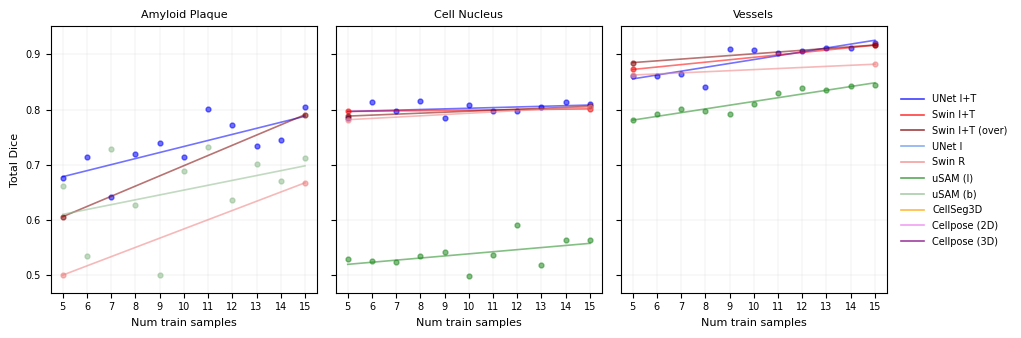

In [55]:
# build dataframe
# df_train = build_train_size_df(ntr_min=5, ntr_max=15)

# save and display in notebook
_ = plot_per_dtype_show_and_save(df_train, outdir=PLOT_OUTDIR, ntr_min=5, ntr_max=15, show=True, close_after=False)
